A centralized parameter configuration block is used to ensure reproducibility and allow easy modification of data sources, time ranges, and aggregation levels without altering analysis logic.

In [1]:
# Parameters Configuration (Reproducible Analysis Settings)
from pathlib import Path

BASE_DIR = Path(".")
AIR_PATH = BASE_DIR / "Airtransport outputFile.xlsx"
VISITOR_PATH = BASE_DIR / "international resident data.csv"
OUTPUT_DIR = BASE_DIR / "ECA outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATE_START = None      # e.g., "2018-01-01" to filter; None = keep all
DATE_END = None        # e.g., "2022-12-31"; None = keep all
RESAMPLE = "M"         # resample frequency: "D"=daily, "W"=weekly, "M"=monthly
SEED = 42              # deterministic seed for any stochastic step (if used)

print(f"✅ 配置完成。输出将保存至: {OUTPUT_DIR}")


✅ 配置完成。输出将保存至: ECA outputs


First, analyze Question 1 to illustrate the overall context of Singapore's aviation industry, and use the ETS forecasting function to predict Singapore’s air transport travel data for the next three years.

✅ 成功！动图已保存至: ECA outputs\figure_1.gif


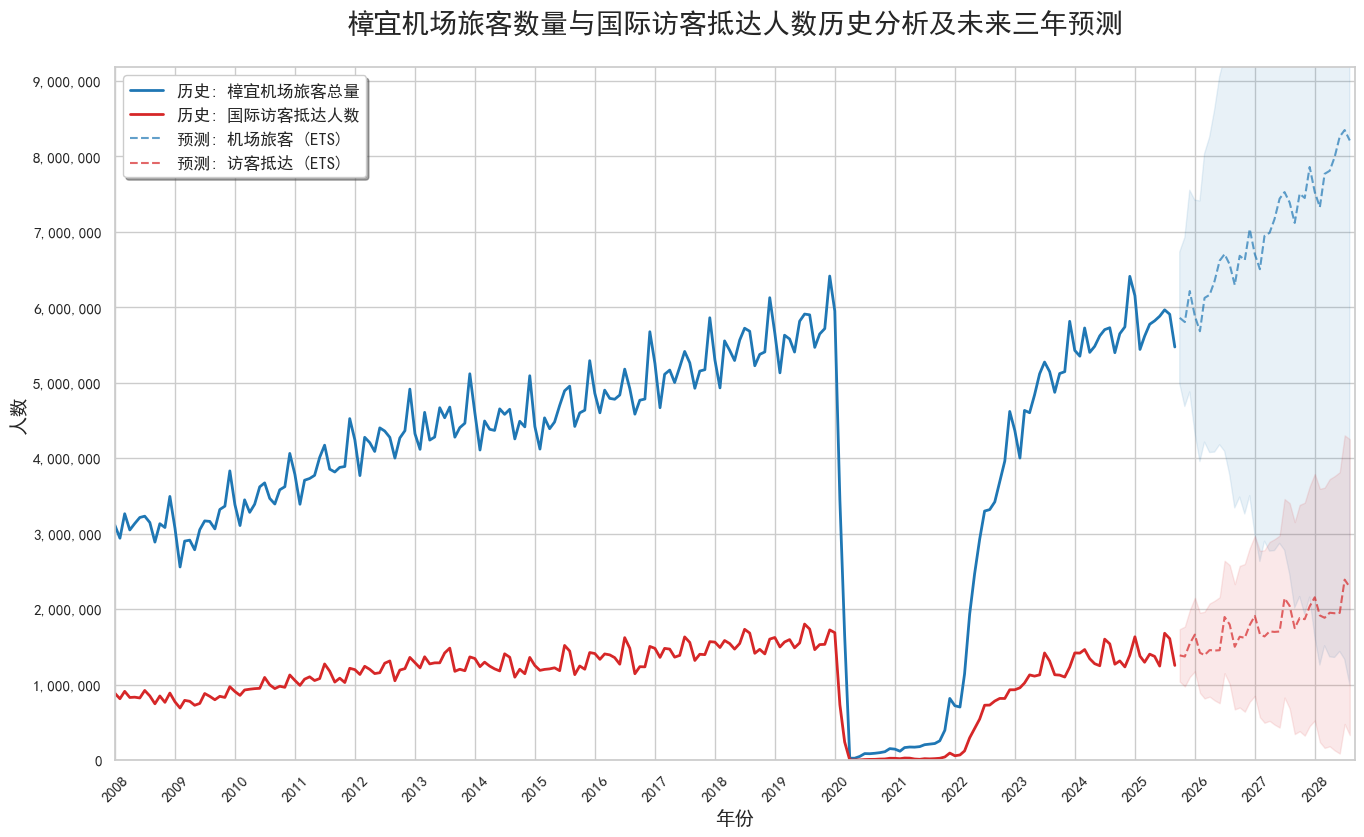

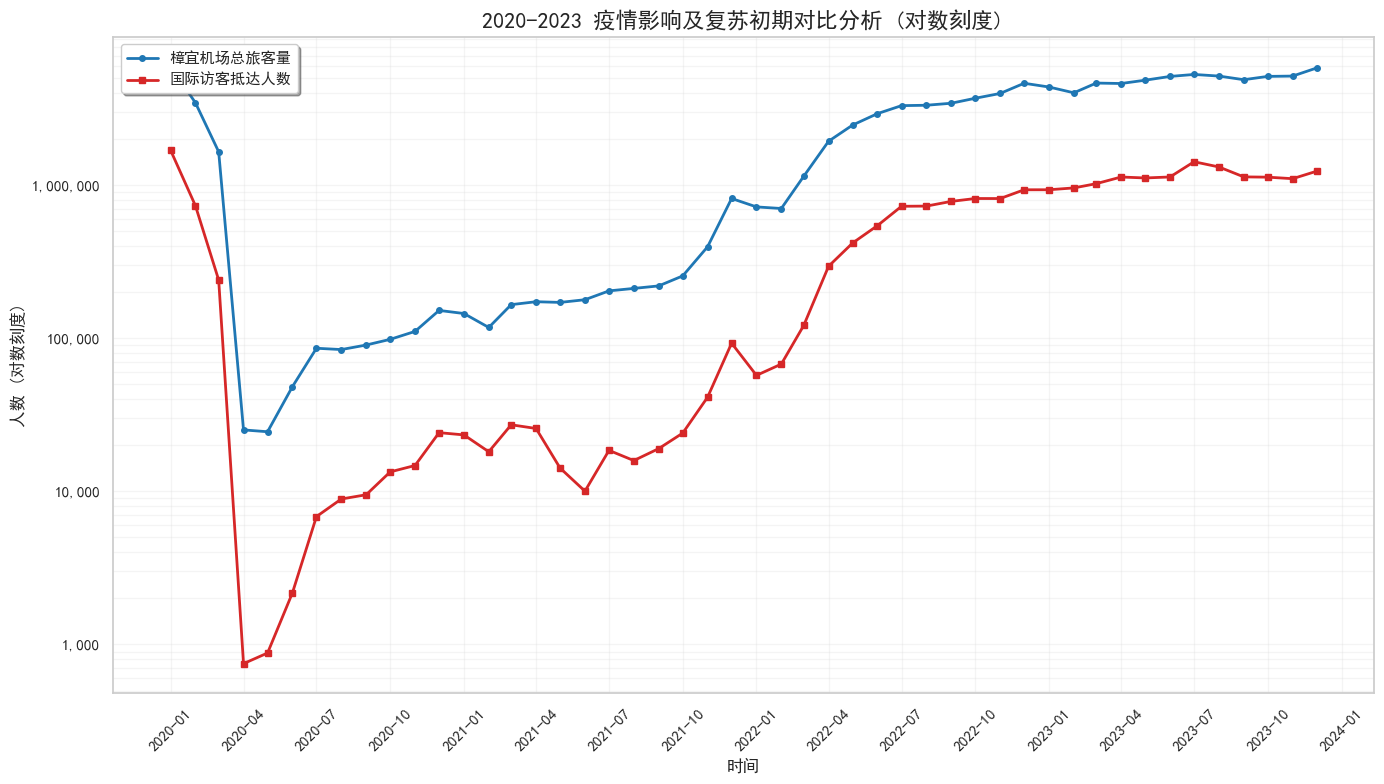

✅ 2020-2023 对数分析图已保存至: ECA outputs\figure_2.png


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, MultipleLocator # 导入 MultipleLocator 用于设置刻度间隔
from matplotlib.animation import FuncAnimation
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

# 1. 风格设置
sns.set_theme(style="whitegrid", font="SimHei", rc={"axes.unicode_minus": False})

# 2. 清洗函数 ：使用使用转置与时间索引重构，确保多表关联的复现性
def load_and_transpose_singstat(path, sheet_name=0):   
    if path.suffix == '.xlsx':
        df = pd.read_excel(path, sheet_name=sheet_name, skiprows=9)   
    else:
        df = pd.read_csv(path, skiprows=9)        
    first_col = df.columns[0]
    df[first_col] = df[first_col].astype(str).str.strip()
    df = df[df[first_col] != 'nan']        
    df = df.set_index(first_col).T 
    df.index = pd.to_datetime(df.index.astype(str).str.strip(), format='%Y %b', errors='coerce')
    df = df[df.index.notnull()].sort_index()        
    df = df.apply(pd.to_numeric, errors='coerce')   
    return df

try:   
    # 3. 数据加载与合并
    df_air_monthly = load_and_transpose_singstat(AIR_PATH, sheet_name='T1')
    df_visitor_monthly = load_and_transpose_singstat(VISITOR_PATH)

    air_col = [c for c in df_air_monthly.columns if "Total Passengers (Number)" in str(c)][0]
    visitor_col = [c for c in df_visitor_monthly.columns if "Total International Visitor Arrivals" in str(c)][0]
    
    compare_df = pd.DataFrame({        
        "樟宜机场总旅客量": df_air_monthly[air_col],        
        "国际访客抵达人数": df_visitor_monthly[visitor_col]    
    }).dropna()

    # 4. ETS预测函数：使用2022年后的数据进行训练，以排除疫情极端值对未来趋势的误导，确保预测的可靠性 
    # # 相比于简单的线性回归，ETS 能够捕捉数据中的季节性和趋势，非常适合具有明显季节规律的旅游数据
    def get_ets_forecast(series, periods=36):
        train_data = series.loc['2022-01-01':].astype(float)
        model = ETSModel(train_data, error="add", trend="add", seasonal="add", seasonal_periods=12)
        fit = model.fit(disp=False)
        forecast = fit.get_prediction(start=len(train_data), end=len(train_data) + periods - 1)
        df_f = forecast.summary_frame()
        df_f.index = pd.date_range(start=train_data.index[-1] + pd.DateOffset(months=1), periods=periods, freq='MS')
        df_f[df_f < 0] = 0
        return df_f

    forecast_air = get_ets_forecast(compare_df["樟宜机场总旅客量"])
    forecast_visitor = get_ets_forecast(compare_df["国际访客抵达人数"])

    # 5. 构造完整时间序列
    full_air = pd.concat([compare_df["樟宜机场总旅客量"], forecast_air['mean']])
    full_visitor = pd.concat([compare_df["国际访客抵达人数"], forecast_visitor['mean']])

    # 6. 动画绘图设置 ---
    fig, ax = plt.subplots(figsize=(16, 9))

    line1, = ax.plot([], [], label='历史: 樟宜机场旅客总量', color='#1f77b4', linewidth=2)
    line2, = ax.plot([], [], label='历史: 国际访客抵达人数', color='#d62728', linewidth=2)
    line1_f, = ax.plot([], [], label='预测: 机场旅客 (ETS)', color='#1f77b4', linestyle='--', linewidth=1.5, alpha=0.7)
    line2_f, = ax.plot([], [], label='预测: 访客抵达 (ETS)', color='#d62728', linestyle='--', linewidth=1.5, alpha=0.7)

    fill_air = ax.fill_between([], [], [], color='#1f77b4', alpha=0.1, label='_nolegend_')# 使用 label='_nolegend_' 避免阴影重复出现在图例中
    fill_visitor = ax.fill_between([], [], [], color='#d62728', alpha=0.1, label='_nolegend_')# 使用 label='_nolegend_' 避免阴影重复出现在图例中

    ax.set_title('樟宜机场旅客数量与国际访客抵达人数历史分析及未来三年预测', fontsize=20, fontweight='bold', pad=25)
    ax.set_xlabel('年份', fontsize=14, fontweight='bold')
    ax.set_ylabel('人数', fontsize=14, fontweight='bold')
    
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.yaxis.set_major_locator(MultipleLocator(1_000_000))
    ax.set_ylim(0, full_air.max() * 1.1) 
    ax.set_xlim(compare_df.index.min(), forecast_air.index.max())

    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45, fontweight='bold')
    plt.yticks(fontweight='bold')

    ax.legend(loc='upper left', fontsize=12, shadow=True, frameon=True)

    def update(frame):
        global fill_air, fill_visitor
        hist_len = len(compare_df)
        
        if frame <= hist_len:
            line1.set_data(compare_df.index[:frame], compare_df.values[:frame, 0])
            line2.set_data(compare_df.index[:frame], compare_df.values[:frame, 1])
        else:
            line1.set_data(compare_df.index, compare_df.values[:, 0])
            line2.set_data(compare_df.index, compare_df.values[:, 1])
            
            f_idx = frame - hist_len
            x_f = forecast_air.index[:f_idx]
            y_f_air = forecast_air['mean'].iloc[:f_idx]
            y_f_visitor = forecast_visitor['mean'].iloc[:f_idx]
            
            line1_f.set_data(x_f, y_f_air)
            line2_f.set_data(x_f, y_f_visitor)
            fill_air.remove()
            fill_visitor.remove()
            
            fill_air = ax.fill_between(x_f, 
                                       forecast_air['pi_lower'].iloc[:f_idx], 
                                       forecast_air['pi_upper'].iloc[:f_idx], 
                                       color='#1f77b4', alpha=0.1)
            fill_visitor = ax.fill_between(x_f, 
                                           forecast_visitor['pi_lower'].iloc[:f_idx], 
                                           forecast_visitor['pi_upper'].iloc[:f_idx], 
                                           color='#d62728', alpha=0.1)
            
        return line1, line2, line1_f, line2_f, fill_air, fill_visitor

    # 7. 生成动画并保存
    total_frames = len(full_air)
    ani = FuncAnimation(fig, update, frames=total_frames, interval=30, blit=False) # blit改为False以支持阴影更新

    gif_save_path = OUTPUT_DIR / "figure_1.gif"
    ani.save(gif_save_path, writer='pillow', fps=25)
    print(f"✅ 成功！动图已保存至: {gif_save_path}")

    # 8. 绘制2020-2023对比分析图
    covid_period_df = compare_df.loc['2020-01-01':'2023-12-31']

    fig_special, ax_spec = plt.subplots(figsize=(14, 8))
    
    ax_spec.plot(covid_period_df.index, covid_period_df["樟宜机场总旅客量"], 
                 label='樟宜机场总旅客量', color='#1f77b4', marker='o', markersize=4, linewidth=2)
    ax_spec.plot(covid_period_df.index, covid_period_df["国际访客抵达人数"], 
                 label='国际访客抵达人数', color='#d62728', marker='s', markersize=4, linewidth=2)

    ax_spec.set_title('2020-2023 疫情影响及复苏初期对比分析 (对数刻度)', fontsize=16, fontweight='bold')
    ax_spec.set_xlabel('时间', fontsize=12)
    ax_spec.set_ylabel('人数 (对数刻度)', fontsize=12)

    # # 应用对数刻度：数据量级差异巨大，用对数坐标轴可以将指数级差距的数据拉回到同一个视觉维度，让2020年-2022年的数据都能清晰可见
    ax_spec.set_yscale('log')

    ax_spec.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
    ax_spec.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) 
    ax_spec.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    
    ax_spec.grid(True, which="both", ls="-", alpha=0.2)
    
    plt.xticks(rotation=45)
    ax_spec.legend(shadow=True, loc='upper left')

    # 9. 生成图表并保存
    plt.tight_layout()
    
    png_save_path = OUTPUT_DIR / "figure_2.png"
    fig_special.savefig(png_save_path, dpi=300)
    
    plt.show() 
    print(f"✅ 2020-2023 对数分析图已保存至: {png_save_path}")

except Exception as e:   
    print(f"❌ 运行过程中出错: {e}")

In the second part, begin analyzing Question 3 by examining visitor arrivals by region, highlighting the differences between regions and laying the groundwork for the subsequent analysis of the "top five markets".

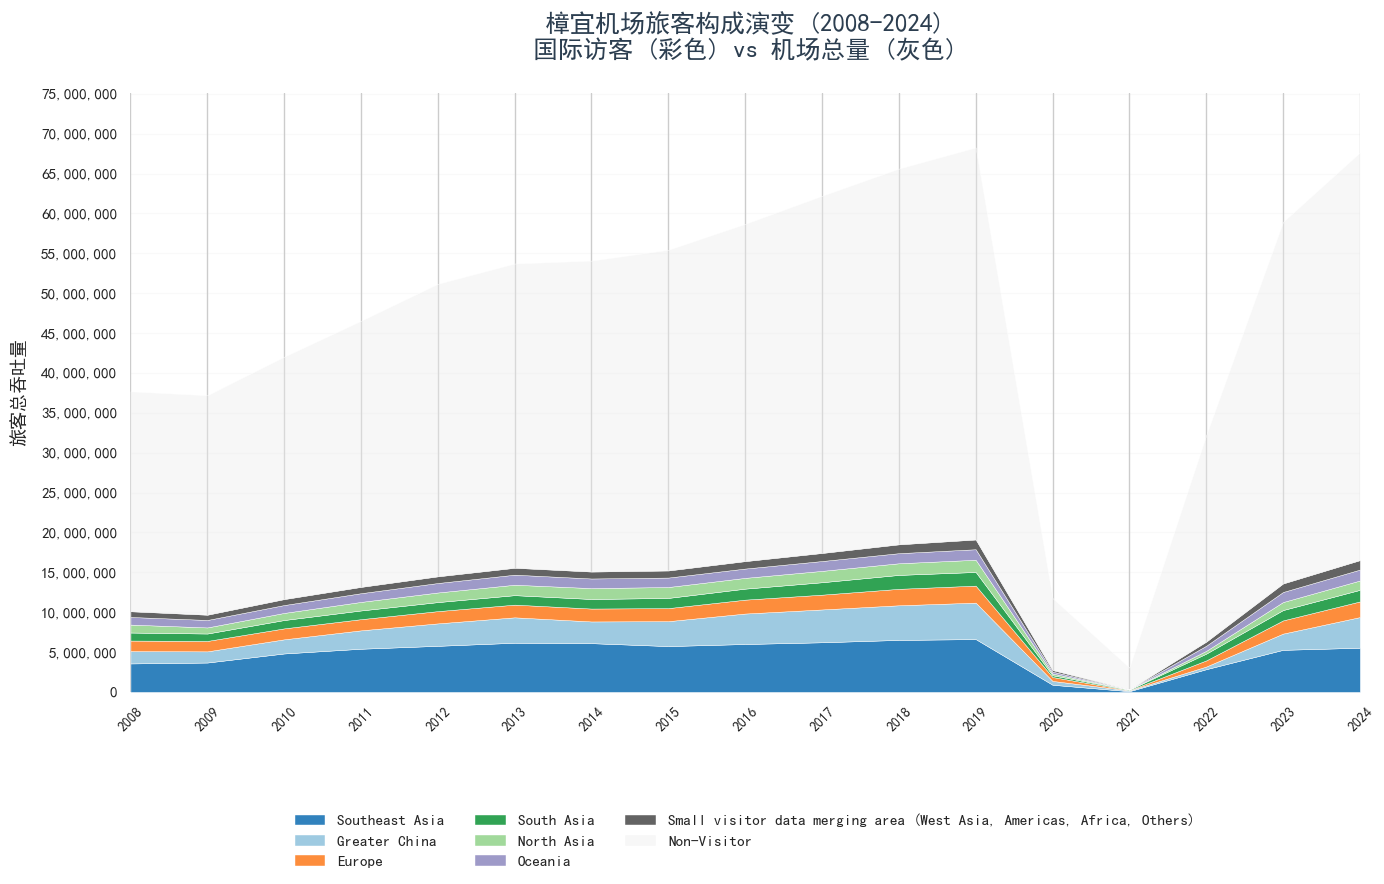

✅ 动态 GIF 已生成并保存至: ECA outputs\figure_3.gif
ℹ️ 已合并以下小份额区域: ['West Asia', 'Americas', 'Africa', 'Others']


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.ticker as ticker 
import re
import numpy as np
from matplotlib import colormaps
from pathlib import Path

def get_col(df, k):
    m = [c for c in df.columns if k.lower() in str(c).lower().replace('\n', ' ').strip()]
    return m[0] if m else None
    
# 1. 数据处理
try:
    # A. 航空数据预处理
    df_air_raw = pd.read_excel(AIR_PATH, sheet_name='T2', skiprows=9)
    df_air = df_air_raw.set_index(df_air_raw.columns[0]).T
    df_air.index = [int(re.search(r'(\d{4})', str(x)).group(1)) if re.search(r'(\d{4})', str(x)) else 0 for x in df_air.index]
    df_air = df_air[df_air.index >= 2008].apply(pd.to_numeric, errors='coerce').fillna(0)
    c_total_name = get_col(df_air, "Total Passengers")

    # B. 访客数据预处理 ：将按月访客数据按年汇总，以便与年度航空到达数据对齐进行年度分析
    df_v_annual = df_visitor_monthly.resample('YE').sum()
    df_v_annual.index = df_v_annual.index.year.astype(int)
    target_regions = ['Southeast Asia', 'Greater China', 'North Asia', 'South Asia', 
                      'West Asia', 'Americas', 'Europe', 'Oceania', 'Africa', 'Others']
    v_cols = {r: get_col(df_v_annual, r) for r in target_regions if get_col(df_v_annual, r)}
    common_years = sorted(list(set(df_air.index) & set(df_v_annual.index)))

    # C. 智能合并逻辑：原始数据包含 10 个以上细分区域。如果全部显示，图表会过于杂乱，图例会过于拥挤
    df_raw_plot = pd.DataFrame(index=common_years)
    for reg_label, actual_col in v_cols.items():
        df_raw_plot[reg_label] = df_v_annual.loc[common_years, actual_col]
    
    total_airport_pax = df_air.loc[common_years, c_total_name]
    avg_shares = df_raw_plot.div(total_airport_pax, axis=0).mean()
    
    # 将平均占比低于 1.5% 的区域（如非洲、西亚等）合并为“小份额数据合并区”。
    # 这样可以解决图表杂乱、图例拥挤的问题，也利于展示对新加坡航空业有重大影响的关键市场。
    small_cols = avg_shares[avg_shares < 0.015].index.tolist()
    large_cols = avg_shares[avg_shares >= 0.015].index.tolist()
    
    df_plot = df_raw_plot[large_cols].copy()
    if small_cols:
        merge_name = "Small visitor data merging area"
        legend_name = f"{merge_name} ({', '.join(small_cols)})"
        df_plot[legend_name] = df_raw_plot[small_cols].sum(axis=1)
    
    visitor_sum = df_raw_plot.sum(axis=1)
    df_plot['Non-Visitor'] = total_airport_pax - visitor_sum

    # 排序：对访客列按平均人数从大到小排序，确保视觉层级从大到小排列
    visitor_cols_in_plot = [c for c in df_plot.columns if c != 'Non-Visitor']
    sorted_visitor_cols = df_plot[visitor_cols_in_plot].mean().sort_values(ascending=False).index.tolist()
    final_order = sorted_visitor_cols + ['Non-Visitor']

# 2. 动画设置 
    fig, ax = plt.subplots(figsize=(14, 9), dpi=100) 
    
    v_colors = colormaps.get_cmap('tab20c')(np.linspace(0, 0.8, len(sorted_visitor_cols)))
    all_colors = list(v_colors) + [(0.92, 0.92, 0.92, 0.4)] 

    def update(frame):
        ax.clear()
        current_years = common_years[:frame+1]
        data_subset = df_plot.loc[current_years, final_order].T
        
        ax.stackplot(current_years, data_subset, labels=final_order, colors=all_colors, edgecolor='white', linewidth=0.3)
        
        ax.set_title("樟宜机场旅客构成演变 (2008-2024)\n国际访客 (彩色) vs 机场总量 (灰色)", 
                      fontsize=18, fontweight='bold', pad=25, color='#2C3E50')
        ax.set_xlim(common_years[0], common_years[-1])
        ax.set_ylim(0, df_air[c_total_name].max() * 1.1)
        ax.set_xticks(common_years) 
        
        ax.yaxis.set_major_locator(ticker.MultipleLocator(5000000))
        
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
        ax.set_ylabel("旅客总吞吐量", fontsize=13, labelpad=10)
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        
        ax.grid(axis='y', linestyle='-', alpha=0.1)
        ax.set_facecolor('white')
        for spine in ax.spines.values():
            spine.set_visible(False)

        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize=11)
        
        plt.tight_layout()

# 3. 生成动画并保存至 OUTPUT_DIR ---
    ani = animation.FuncAnimation(fig, update, frames=len(common_years), interval=400, repeat=True)
    save_path = OUTPUT_DIR / "figure_3.gif"
    ani.save(str(save_path), writer='pillow')
    
    plt.show()
    print(f"✅ 动态 GIF 已生成并保存至: {save_path}")
    if small_cols:
        print(f"ℹ️ 已合并以下小份额区域: {small_cols}")

except Exception as e:
    import traceback
    print(f"❌ 运行失败: {e}")
    traceback.print_exc()

In the third part, analyze Question 2 by focusing on key points related to the COVID-19 pandemic. Compare air transport and visitor arrivals before, during, and after the pandemic to identify the relationship between the two, while also selecting the "top five markets contributing most to the recovery" for an in-depth analysis.

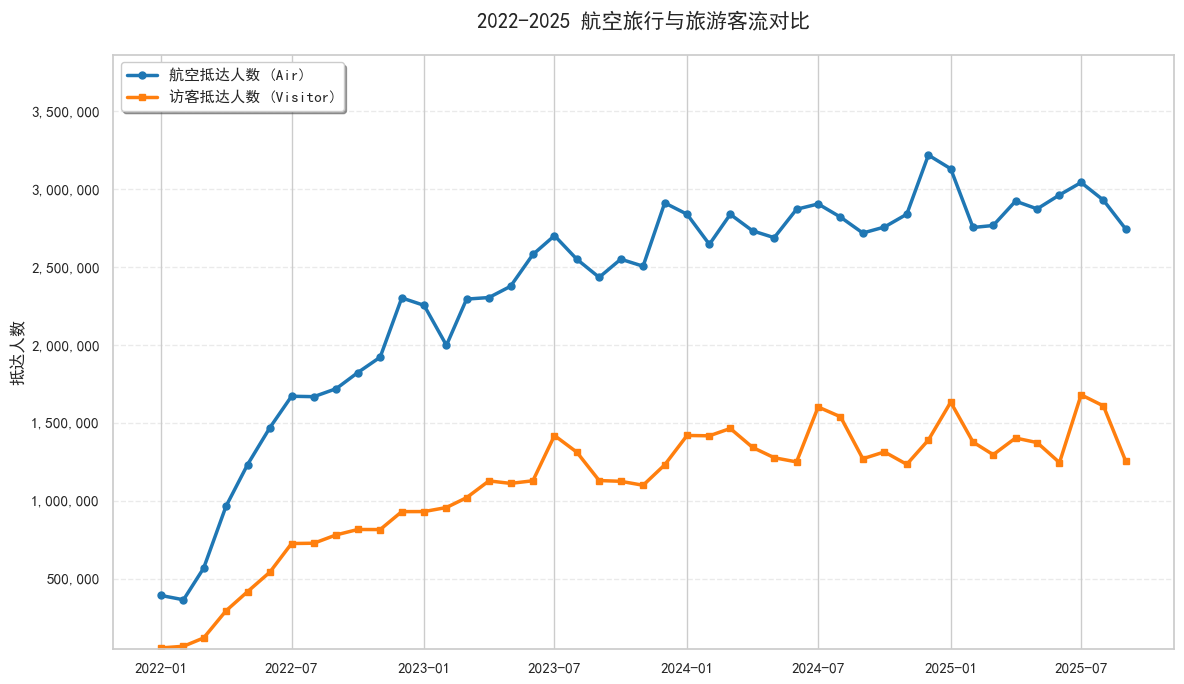

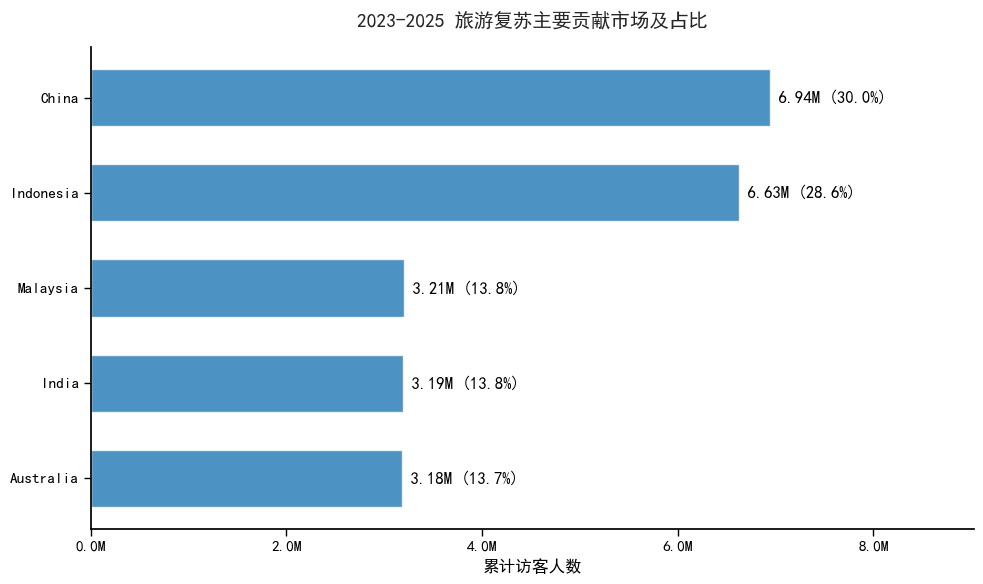

📂 所有修改已完成并保存至: C:\Users\Ran\ECA outputs


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import MultipleLocator

# 1. 环境设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('future.no_silent_downcasting', True)
save_path = OUTPUT_DIR

# 2. 定义数据清洗函数，保证日期解析正确、列名标准化，并将文本数字转换为数值型，方便分析
def clean_and_parse_data(df):
    df = df.set_index(df.columns[0]).T
    df.index = pd.to_datetime([str(i).strip() for i in df.index], format='%Y %b', errors='coerce')
    df = df[df.index.notnull()].sort_index()
    df.columns = [str(c).replace('\n', ' ').strip() for c in df.columns]
    return df

def to_num(s): 
    return pd.to_numeric(s.astype(str).str.replace(',', ''), errors='coerce')

try:
    df_air_raw = pd.read_excel(AIR_PATH, sheet_name='T1', skiprows=9)
    df_air = clean_and_parse_data(df_air_raw)
    df_v_raw = pd.read_csv(VISITOR_PATH, skiprows=9)
    df_v = clean_and_parse_data(df_v_raw)

    a_col = [c for c in df_air.columns if 'Passengers Arriving' in c][0]
    v_col = [c for c in df_v.columns if 'Total Inter' in c][0]

# 3. 折线图：航空旅行与旅游客流对比
    df_trend = pd.DataFrame({
        'Air': to_num(df_air[a_col]),
        'Visitor': to_num(df_v[v_col])
    }).loc['2022-01-01':].dropna()
    
    if not df_trend.empty:
        fig1, ax1 = plt.subplots(figsize=(12, 7))
        
        ax1.plot(df_trend.index, df_trend['Air'], color='#1f77b4', marker='o', 
                 markersize=5, lw=2.5, label='航空抵达人数 (Air)')
        ax1.plot(df_trend.index, df_trend['Visitor'], color='#ff7f0e', marker='s', 
                 markersize=5, lw=2.5, label='访客抵达人数 (Visitor)')
        
        ax1.set_ylabel('抵达人数', fontsize=12, fontweight='bold') 
        ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
        ax1.yaxis.set_major_locator(MultipleLocator(500000))  

        y_max = max(df_trend['Air'].max(), df_trend['Visitor'].max())
        ax1.set_ylim(df_trend[['Air', 'Visitor']].min().min() * 0.9, y_max * 1.2)

        ax1.legend(loc='upper left', frameon=True, shadow=True, fontsize=11)
        ax1.grid(axis='y', linestyle='--', alpha=0.4)
        
        plt.title('2022-2025 航空旅行与旅游客流对比', fontsize=15, fontweight='bold', pad=20)
        
        plt.tight_layout()
        fig1.savefig(save_path / "figure_4.png", dpi=300)
        plt.show()


# 4. 条形图：贡献最大的前五个市场

    ## 排除区域合计列和已汇总区域，筛选 2023-2025 年数据，按国家/市场总访客数排序，取前五
    exclude = ['Total International Visitor Arrivals By Place Of Residence', 'Southeast Asia', 
               'Greater China', 'North Asia', 'South Asia', 'West Asia', 'Americas', 'Europe','Oceania','Africa']
    country_cols = [c for c in df_v.columns if not any(ex.lower() in c.lower() for ex in exclude)]
    
    df_top5_range = df_v[country_cols].loc['2023-01-01':'2025-09-30'].apply(to_num)
    top5_results = df_top5_range.sum().sort_values(ascending=False).head(5)
    total_v = top5_results.sum()

    if not top5_results.empty:
        fig2, ax = plt.subplots(figsize=(10, 6))
        clean_names = [n.split('(')[0].strip() for n in top5_results.index]
        
        bars = ax.barh(clean_names[::-1], top5_results.values[::-1], color='#1f77b4', alpha=0.8, height=0.6)

        plt.title('2023-2025 旅游复苏主要贡献市场及占比', fontsize=14, fontweight='bold', pad=15)
        plt.xlabel('累计访客人数', fontweight='bold', color='black')
        
        ax.tick_params(axis='both', which='both', bottom=True, left=True, 
                       colors='black', length=5, width=1)
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_visible(True)

        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
        ax.grid(False) 

        for bar in bars:
            width = bar.get_width()
            percentage = (width / total_v) * 100
            ax.text(width, bar.get_y() + bar.get_height()/2, f' {width/1e6:.2f}M ({percentage:.1f}%)', 
                    va='center', fontweight='bold', color='black')
        
        ax.set_xlim(0, top5_results.max() * 1.3) 
        sns.despine(ax=ax, left=False, bottom=False) 
        
        plt.tight_layout()
        fig2.savefig(save_path / "figure_5.png", dpi=300)
        plt.show()

    print(f"📂 所有修改已完成并保存至: {save_path.absolute()}")

except Exception as e:
    print(f"❌ 运行失败: {e}")

Finally, analyze Question 4 by shifting the focus to the Chinese market and examining the trends in Chinese visitor data over the past 15 years.

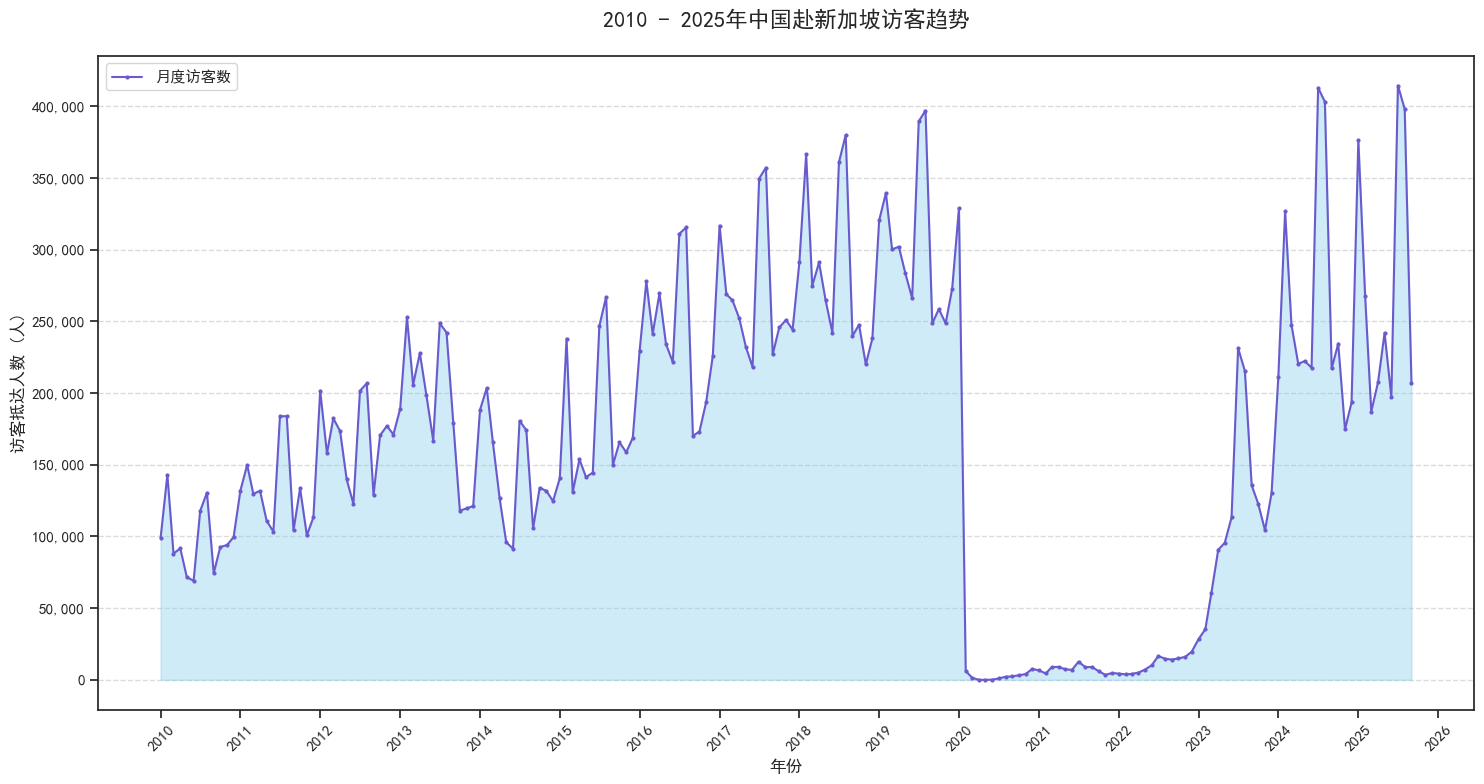

✅ 处理完成。


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker  
from pathlib import Path

# 1. 设置 Seaborn 风格和中文显示
sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False 

# 2. 读取并精确定位中国数据
df_raw = pd.read_csv(VISITOR_PATH, skiprows=9)
df_raw.columns = df_raw.columns.str.strip()
df_raw['Data Series'] = df_raw['Data Series'].str.strip()
df_china = df_raw[df_raw['Data Series'] == 'China'].copy()

# 3. 数据重塑：将“列为月份”的宽表转换成长表，方便时间序列分析
df_china_melted = df_china.melt(id_vars=['Data Series'], var_name='Raw_Date', value_name='Visitors')
df_china_melted['Date'] = pd.to_datetime(df_china_melted['Raw_Date'], format='%Y %b', errors='coerce')

# 4. 过滤 2010-2025 年的数据并排序
df_final = df_china_melted.dropna(subset=['Date']) 
df_final = df_final[(df_final['Date'].dt.year >= 2010) & (df_final['Date'].dt.year <= 2025)]
df_final = df_final.sort_values('Date') 

# 5. 可视化绘制
fig, ax = plt.subplots(figsize=(15, 8))

# 绘制面积图和折线
ax.fill_between(df_final['Date'], df_final['Visitors'], color="skyblue", alpha=0.4)
ax.plot(df_final['Date'], df_final['Visitors'], color="Slateblue", marker='.', markersize=4, linewidth=1.5, label='月度访客数')

ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(50000))
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title('2010 - 2025年中国赴新加坡访客趋势', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('访客抵达人数 (人)', fontsize=12)
plt.xlabel('年份', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=True)

plt.xticks(rotation=45) # 旋转年份标签防止重叠
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure_6.png", dpi=300)
plt.show()

print(f"✅ 处理完成。")

In this final part, the focus should be on analyzing the changes in Chinese visitor data following the implementation of the 30-day visa-free policy, in order to evaluate the policy's effectiveness and provide targeted recommendations for future policy development.

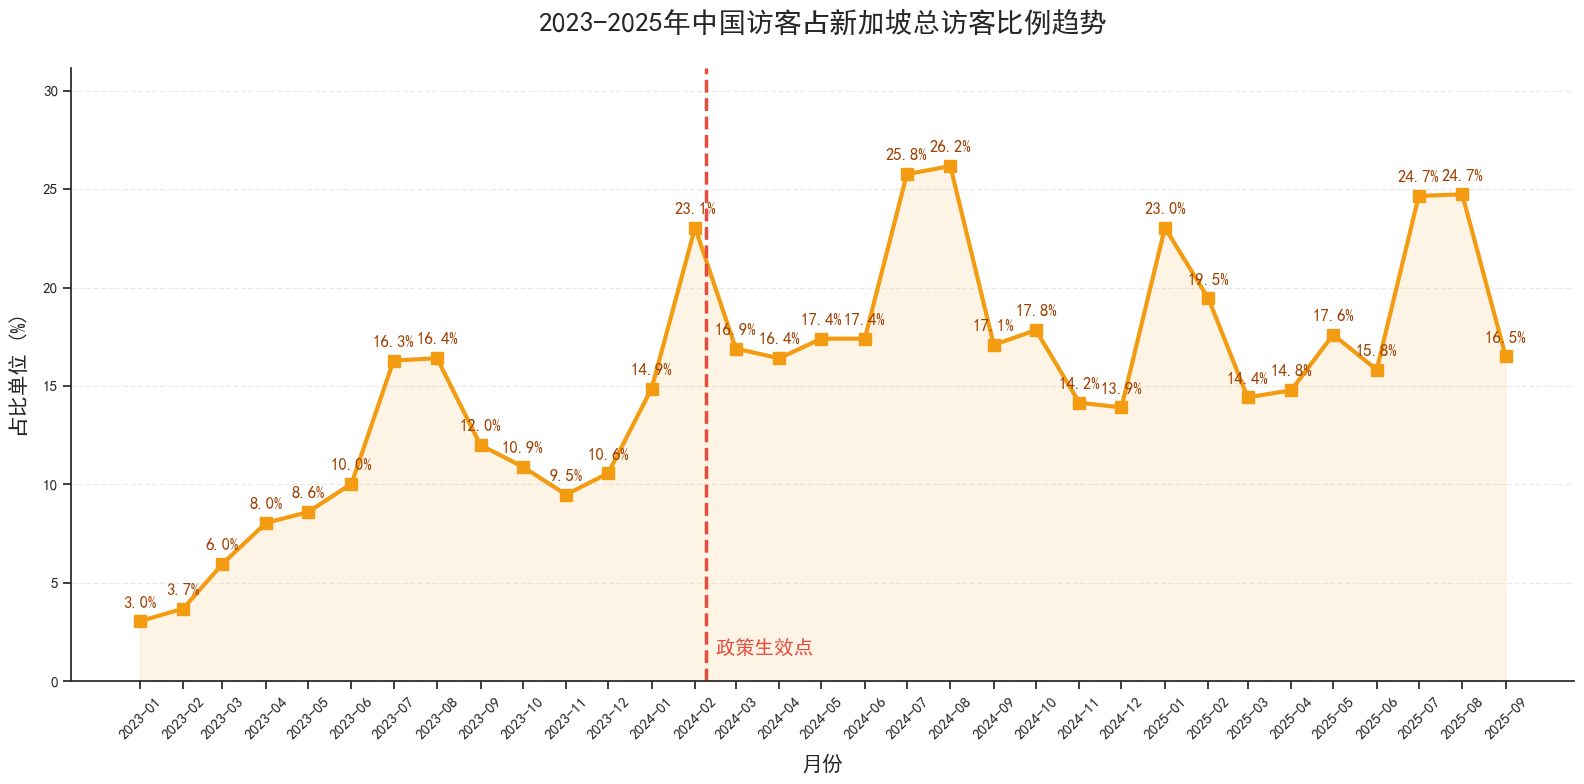

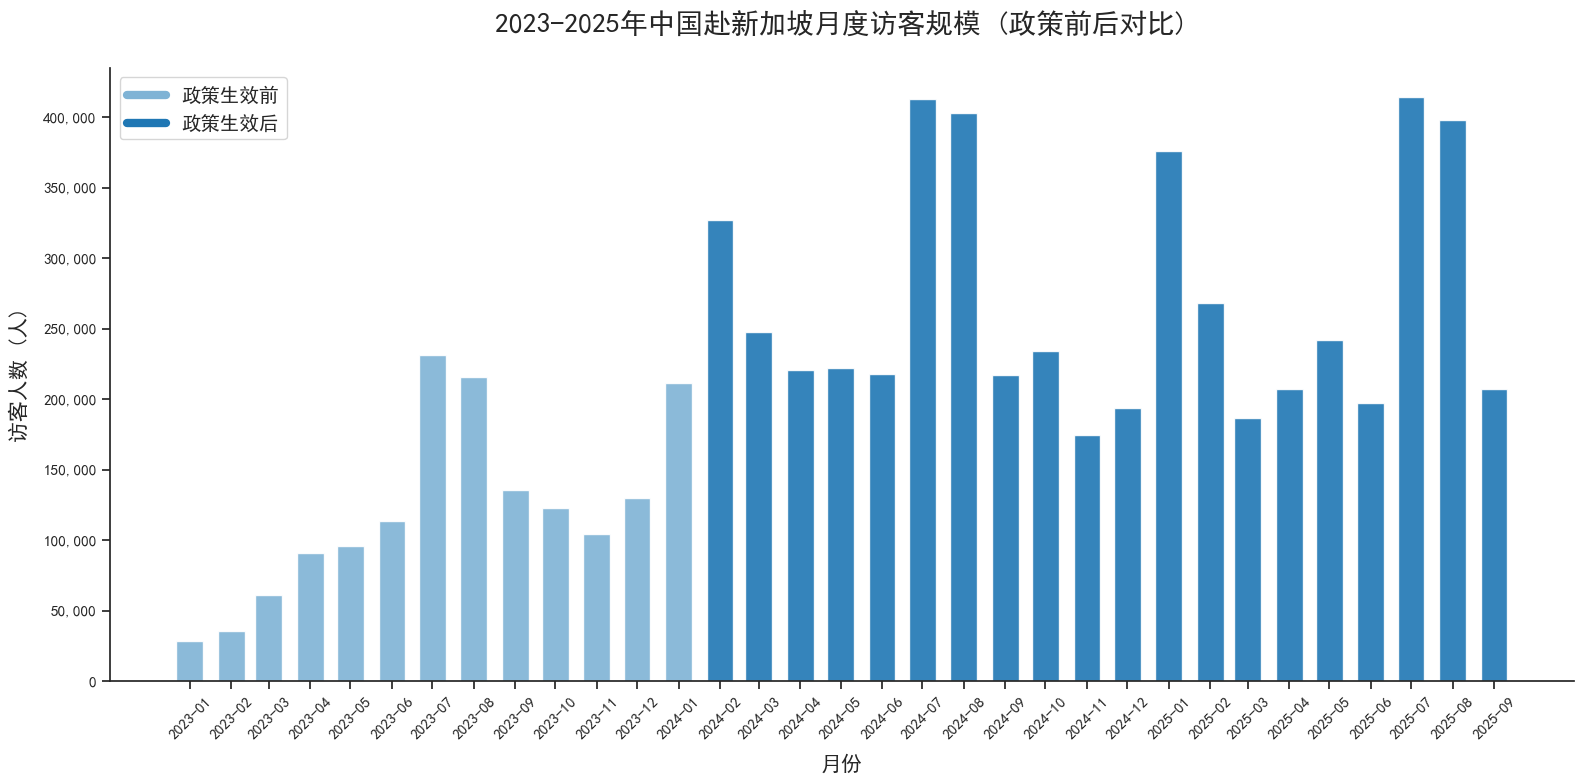

✅ 处理完成


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from pathlib import Path
from matplotlib.lines import Line2D

# 1. 设置绘图美化参数
sns.set_theme(style="ticks") 
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 

# 2. 数据读取与处理
df_raw = pd.read_csv(VISITOR_PATH, skiprows=9)
df_raw.columns = df_raw.columns.str.strip()
df_raw['Data Series'] = df_raw['Data Series'].str.strip()

df_china = df_raw[df_raw['Data Series'] == 'China'].copy()
df_total = df_raw[df_raw['Data Series'] == 'Total International Visitor Arrivals By Place Of Residence'].copy()

#将宽表（列为月份）转换成长表，便于按时间绘图
df_c = df_china.melt(id_vars=['Data Series'], var_name='Raw_Date', value_name='China_Visitors')
df_t = df_total.melt(id_vars=['Data Series'], var_name='Raw_Date', value_name='Total_Visitors')

df_merge = pd.merge(df_c[['Raw_Date', 'China_Visitors']], df_t[['Raw_Date', 'Total_Visitors']], on='Raw_Date')
df_merge['Date'] = pd.to_datetime(df_merge['Raw_Date'], format='%Y %b', errors='coerce')
df_merge['China_Share'] = (df_merge['China_Visitors'] / df_merge['Total_Visitors']) * 100
df_plot = df_merge[(df_merge['Date'] >= '2023-01-01') & (df_merge['Date'] <= '2025-09-30')].sort_values('Date')

# 定义政策关键点
policy_start_date = pd.Timestamp('2024-02-01')

# 3.绘制折线图：中国访客占比 
plt.figure(figsize=(16, 8))
plt.plot(df_plot['Date'], df_plot['China_Share'], color='#f39c12', marker='s', linewidth=3, markersize=8, label='占比 (%)')
plt.fill_between(df_plot['Date'], df_plot['China_Share'], color='#f39c12', alpha=0.1)

for x, y in zip(df_plot['Date'], df_plot['China_Share']):
    plt.text(x, y + 0.6, f'{y:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold', color='#a04000')

# 标记政策生效点
visa_free_date = pd.Timestamp('2024-02-09')
plt.axvline(visa_free_date, color='#e74c3c', linestyle='--', linewidth=2.5)
plt.text(visa_free_date, plt.gca().get_ylim()[1]*0.05, ' 政策生效点', color='#e74c3c', fontweight='bold', fontsize=14)

plt.title('2023-2025年中国访客占新加坡总访客比例趋势', fontsize=20, pad=25, fontweight='bold')
plt.ylabel('占比单位 (%)', fontsize=15, labelpad=10)
plt.xlabel('月份', fontsize=15, labelpad=10)

plt.ylim(0, df_plot['China_Share'].max() + 5)
plt.yticks(fontsize=11)
plt.xticks(df_plot['Date'], df_plot['Date'].dt.strftime('%Y-%m'), rotation=45, fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure_7.png", dpi=300)
plt.show()

# 4.绘制柱状图：中国访客人数规模
plt.figure(figsize=(16, 8))

# 颜色优化：政策前蓝色浅，政策蓝色深
colors = ['#7fb3d5' if d < policy_start_date else '#1f77b4' for d in df_plot['Date']]

bars = plt.bar(df_plot['Date'], df_plot['China_Visitors'], color=colors, width=20, alpha=0.9)
legend_elements = [Line2D([0], [0], color='#7fb3d5', lw=6, label='政策生效前'),
                   Line2D([0], [0], color='#1f77b4', lw=6, label='政策生效后')]
plt.legend(handles=legend_elements, loc='upper left', prop={'size': 14}, frameon=True)

plt.title('2023-2025年中国赴新加坡月度访客规模 (政策前后对比)', fontsize=20, pad=25, fontweight='bold')
plt.ylabel('访客人数 (人)', fontsize=15, labelpad=10)
plt.xlabel('月份', fontsize=15, labelpad=10)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.yticks(fontsize=11)
plt.xticks(df_plot['Date'], df_plot['Date'].dt.strftime('%Y-%m'), rotation=45, fontsize=11)

sns.despine()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figure_8.png", dpi=300)
plt.show()


print("✅ 处理完成")